# Imports, functions and data processing

In [24]:
import os, sys
import utils.data_processing as dp
import utils.pair_methods as pm
import scipy
from datetime import datetime
import re
from collections import defaultdict, OrderedDict
#torch
import torch
from torchvision.models import alexnet
from torchvision import transforms as T
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.metrics.pairwise import cosine_similarity
from scipy.optimize import linear_sum_assignment

#QUBOvert
import qubovert as qv
from qubovert import boolean_var, QUBO,PUBO
from qubovert.sim import anneal_qubo, anneal_pubo
from dwave.samplers import SimulatedAnnealingSampler
from dimod import BinaryQuadraticModel
import dimod


## Functions until the point I know what's going on
_path\_joiner_
+ using the following function, I don't need to worry about image paths being right or not
+ I can just pass the .mat file names to the _path\_joiner_ and generate the path for the file

In [25]:
# step 0 : Handling folder paths

def path_joiner(image_name , root_dir=None): #recursive search for the image
    if root_dir is None:
        root_dir = os.getcwd()
    for dirpath , _, filenames in os.walk(root_dir):
        if image_name in filenames:
            return os.path.join(dirpath, image_name)

#usage
mat_files = ['Cars_006a.mat','Cars_007a.mat','Cars_008b.mat']
paths = []
for fi in mat_files:
    paths.append(path_joiner(fi))
print(paths)

["d:\\University\\Master'sDegree\\Quantum\\10.Quantum Hardware Design and Optimization and Quantum Computing\\Quantum Computing\\project\\QPermutationSynch\\PF-dataset\\car(G)\\Cars_006a.mat", "d:\\University\\Master'sDegree\\Quantum\\10.Quantum Hardware Design and Optimization and Quantum Computing\\Quantum Computing\\project\\QPermutationSynch\\PF-dataset\\car(G)\\Cars_007a.mat", "d:\\University\\Master'sDegree\\Quantum\\10.Quantum Hardware Design and Optimization and Quantum Computing\\Quantum Computing\\project\\QPermutationSynch\\PF-dataset\\car(G)\\Cars_008b.mat"]


# extracting and handling keypoints from .mat files
+ _keypoints\_dict_ accepts as input the list of names of the .mat files
+ _keypoints\_list_ accepts as input the list of paths of .mat files

In [26]:
def keypoint(image_path):
    keypoints1 = scipy.io.loadmat(image_path)["pts_coord"]
    return keypoints1
#extract keypoints of several images
def keypoints_list(image_paths: list):
    keypoints = []
    for image_path in image_paths:
        keypoints1 = keypoint(image_path)
        keypoints.append(keypoints1)
    return keypoints

def keypoints_dict(image_names: list):
    keypoints = {}
    for image_name in image_names:
        base_name = os.path.splitext(image_name)[0]  # remove extension
        full_path = path_joiner(image_name)
        if full_path:
            keypoints[base_name] = keypoint(full_path)
        else:
            print(f"[Warning] image not found: {image_name}")
    return keypoints
points_list = keypoints_list(paths)
print(f'This is the keypoints list {points_list}')
points_dic = keypoints_dict(mat_files)
print(f'This is the keypoints dict {points_dic}')

This is the keypoints list [array([[ 47.93528064, 151.86426117,  45.965063  ,  69.60767468,
        109.99713631,  93.74284078,  94.23539519, 220.82187858,
         37.59163803, 131.17697595],
       [ 98.15864834, 121.80126002,  57.2766323 ,  54.81386025,
         45.94788087,  86.82989691, 115.39805269, 108.50229095,
         80.91924399,  61.70962199]]), array([[ 38.44802   , 128.33906116,  24.28337108,  50.43349215,
         80.39717254,  77.67320159,  76.58361322, 156.12356479,
         21.55940014,  97.28579239],
       [159.21073186, 177.73373428, 115.62719675, 108.00007811,
         98.7385769 , 146.68046552, 179.36811685, 154.30758416,
        134.69499336, 127.61266891]]), array([[ 24.22058824, 117.125     ,  14.44117647,  24.22058824,
         67.73897059,  67.25      ,  72.13970588, 144.99632353,
         12.48529412, 102.94485294],
       [167.35845588, 173.22610294, 143.39889706, 128.72977941,
        109.17095588, 146.82169118, 174.20404412, 145.84375   ,
        160.023

# AlexNet used for feature extraction from the images
+ conv4 is used because this layer delivers the best balance between feature readability and usability
+ otherwise conv5 can be used, which delivers a more flattened feature list
+ _visualize\_similarity_ saves pairwise heatmaps of similarity points between images

In [27]:
def alexnet_feature_extractor(layer= 'conv4'):
    model = alexnet(pretrained=True)
    model.eval()
    if layer == 'conv4':
        return torch.nn.Sequential(*list(model.features)[:10])
    elif layer == 'conv5':
        return torch.nn.Sequential(*list(model.features)[:12])
    else:
        raise ValueError("Invalid layer. Choose 'conv4' or 'conv5'.")
#extract features from keypoints
def extract_features(keypoints_dict, patch_size=64, layer='conv4'):
    feature_extractor = alexnet_feature_extractor(layer)
    transform = T.Compose([
        T.Resize((227, 227)),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    feature_extractor.to(device)
    features = {}

    for image_name, keypoints in keypoints_dict.items():
        img_path = path_joiner(image_name + '.png')
        img = Image.open(img_path).convert('RGB')
        img_np = np.array(img)
        feature_list = []

        for (x, y) in keypoints.T:
            x, y = int(round(x)), int(round(y))
            x1 = max(0, x - patch_size // 2)
            y1 = max(0, y - patch_size // 2)
            x2 = min(img.width, x + patch_size // 2)
            y2 = min(img.height, y + patch_size // 2)

            patch = img.crop((x1, y1, x2, y2))
            patch_tensor = transform(patch).unsqueeze(0).to(device)
            with torch.no_grad():
                feat = feature_extractor(patch_tensor)
                feat = feat.mean(dim=[2, 3]) # to flatten the output dimensions
            feature_list.append(feat.squeeze().cpu().numpy())

        features[image_name] = np.stack(feature_list)
    return features
def visualize_similarity(features_dict, image_list):
    os.makedirs("data_collection", exist_ok=True)

    for i in range(len(image_list)):
        for j in range(i + 1, len(image_list)):
            img1 = image_list[i]
            img2 = image_list[j]
            feats1 = features_dict[img1]
            feats2 = features_dict[img2]
            sim_matrix = cosine_similarity(feats1, feats2)

            plt.figure(figsize=(6, 5))
            plt.imshow(sim_matrix, cmap='viridis')
            plt.colorbar(label='Cosine Similarity')
            plt.title(f"Similarity: {img1} vs {img2}")
            plt.xlabel(f"{img2} keypoints")
            plt.ylabel(f"{img1} keypoints")
            plt.tight_layout()

            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            filename = f"data_collection/sim_{img1}_vs_{img2}_{timestamp}.png"
            plt.savefig(filename)
            plt.close()
            print(f"[✓] Saved: {filename}")
features = extract_features(points_dic)
print(features)
visualize_similarity(features, list(features.keys()))

c:\Users\sasan\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\sasan\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


{'Cars_006a': array([[0.6327961 , 0.6570724 , 0.43500638, ..., 0.12524807, 0.94820446,
        0.25369614],
       [0.6472052 , 0.7465545 , 0.29996347, ..., 0.31832656, 0.44847858,
        0.7318862 ],
       [0.6550388 , 0.5805156 , 0.519704  , ..., 0.2887706 , 0.6994099 ,
        0.31993425],
       ...,
       [0.43621403, 0.41626948, 1.5666335 , ..., 1.1597884 , 0.5372449 ,
        0.16799997],
       [0.5433742 , 0.7008581 , 0.5364041 , ..., 0.08042818, 0.8331341 ,
        0.3312085 ],
       [0.37006027, 0.66797894, 0.9629723 , ..., 0.29395217, 0.4494582 ,
        0.2073065 ]], dtype=float32), 'Cars_007a': array([[0.8054076 , 0.31992558, 0.35503426, ..., 0.5955565 , 0.48035055,
        0.25003266],
       [1.2447602 , 0.66127527, 0.3204016 , ..., 0.28860936, 0.679289  ,
        0.43859968],
       [0.7458177 , 0.19756278, 0.6287172 , ..., 0.4006805 , 0.43598127,
        0.30020928],
       ...,
       [0.9570889 , 0.15233341, 0.7297584 , ..., 0.14203486, 0.56593704,
        0.480

# printing the similarity and cost matrices
+ cost matrix will be used in the hungarian algorithm and eventually for calculating the noisy permutation matrices

In [28]:
def print_similarity_matrix(features_dict): # print the similarity(cost matrix)
    image_list = list(features_dict.keys())

    for i in range(len(image_list)):
        for j in range(i + 1, len(image_list)):
            img1 = image_list[i]
            img2 = image_list[j]

            feats1 = features_dict[img1]
            feats2 = features_dict[img2]
            sim_matrix = cosine_similarity(feats1, feats2)

            print(f"\n=== Cosine Similarity Matrix: {img1} vs {img2} ===")
            for row in sim_matrix:
                print("  ".join(f"{val:.2f}" for val in row))

def print_cost_matrix(features_dict): # this will be used for Hungarian algorithm
    image_list = list(features_dict.keys())

    for i in range(len(image_list)):
        for j in range(i + 1, len(image_list)):
            img1 = image_list[i]
            img2 = image_list[j]

            feats1 = features_dict[img1]
            feats2 = features_dict[img2]
            sim_matrix = cosine_similarity(feats1, feats2)
            cost_matrix = 1 - sim_matrix

            print(f"\n=== Cost Matrix (1 - cosine): {img1} vs {img2} ===")
            for row in cost_matrix:
                print("  ".join(f"{val:.2f}" for val in row))
#
print("This is the similarity matrix:")
print_similarity_matrix(features)
print("This is the cost matrix:")
print_cost_matrix(features)

This is the similarity matrix:

=== Cosine Similarity Matrix: Cars_006a vs Cars_007a ===
0.79  0.80  0.76  0.78  0.79  0.81  0.72  0.79  0.73  0.79
0.81  0.84  0.77  0.80  0.79  0.74  0.71  0.78  0.78  0.77
0.73  0.76  0.79  0.78  0.79  0.71  0.66  0.79  0.77  0.76
0.69  0.74  0.74  0.75  0.76  0.70  0.62  0.76  0.72  0.74
0.69  0.72  0.70  0.72  0.75  0.70  0.65  0.75  0.70  0.75
0.67  0.69  0.67  0.71  0.70  0.76  0.64  0.72  0.63  0.70
0.66  0.65  0.61  0.67  0.66  0.77  0.77  0.66  0.58  0.71
0.67  0.71  0.67  0.70  0.72  0.72  0.67  0.76  0.62  0.73
0.77  0.79  0.78  0.80  0.79  0.77  0.67  0.79  0.76  0.77
0.71  0.74  0.73  0.75  0.77  0.75  0.68  0.78  0.71  0.78

=== Cosine Similarity Matrix: Cars_006a vs Cars_008b ===
0.76  0.80  0.76  0.79  0.75  0.79  0.69  0.81  0.78  0.81
0.79  0.84  0.78  0.77  0.67  0.72  0.66  0.81  0.79  0.76
0.73  0.78  0.74  0.77  0.74  0.74  0.67  0.78  0.74  0.75
0.68  0.73  0.71  0.73  0.69  0.70  0.62  0.74  0.70  0.72
0.70  0.75  0.72  0.73  0.7

+ _pairwise\_permutation_ uses the hungarian algorithm to calculate _P\_ij_
+ the hungarian algorithm is delivered through _linear\_sum\_assignment_ that is compatible with numpy datatypes

In [29]:
def pairwise_permutations(features_dict) -> dict: # compute the P_ij
    P = {}
    image_list = list(features_dict.keys())

    for i in range(len(image_list)):
        for j in range(i + 1, len(image_list)):
            img1 = image_list[i]
            img2 = image_list[j]

            feats1 = features_dict[img1]
            feats2 = features_dict[img2]
            similarity = cosine_similarity(feats1, feats2)
            cost_matrix = 1 - similarity

            row_ind, col_ind = linear_sum_assignment(cost_matrix)
            n = len(row_ind)
            perm_matrix = np.zeros((n, n), dtype=int)
            perm_matrix[row_ind, col_ind] = 1

            key = f"P{i+1}{j+1}"
            P[key] = perm_matrix
    return P
#
P = pairwise_permutations(features)
print("these are the pairwise permutations")
print(P)

these are the pairwise permutations
{'P12': array([[1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
       [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 1]]), 'P13': array([[0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
       [1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
       [0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
       [0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
       [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 1]]), 'P23': array([[1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
       [0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
  

In [30]:

#QUBO formulation using D-wave SDK
def qubo_formulation(P: dict, num_views: int, penalty=1.5, cycle_penalty=2.0):
    # Initialize the BQM
    bqm = dimod.BinaryQuadraticModel('BINARY')
    
    # Get the number of keypoints from one relative permutation matrix
    valu = next(iter(P.values()))
    n = len(valu[0])
    
    # Create absolute permutation variables
    absolute_matrices = {}
    for i in range(num_views):
        if i == 0:  # First matrix is identity
            absolute_matrices[f'X{i+1}'] = np.eye(n, dtype=int).tolist()
        else:
            absolute_matrices[f'X{i+1}'] = [
                [f'x{i+1}_{k}_{l}' for l in range(n)]  # D-Wave style variable naming
                for k in range(n)
            ]
    
    # === Objective term: matching error ===
    for i in range(num_views):
        for j in range(i + 1, num_views):
            key = f'P{i+1}{j+1}'
            P_ij = P[key]
            for k in range(n):
                for l in range(n):
                    # Calculate Xi * Xj^T term
                    if i == 0:  # If using identity matrix
                        for r in range(n):
                            if absolute_matrices[f'X{i+1}'][k][r] == 1:
                                var_j = absolute_matrices[f'X{j+1}'][l][r]
                                # Add linear and quadratic terms
                                bqm.add_variable(var_j, P_ij[k,l])
                    else:
                        for r in range(n):
                            var_i = absolute_matrices[f'X{i+1}'][k][r]
                            var_j = absolute_matrices[f'X{j+1}'][l][r]
                            # Add quadratic terms for the product
                            bqm.add_interaction(var_i, var_j, -2 * P_ij[k,l] + 1)
                            # Add linear terms
                            bqm.add_variable(var_i, P_ij[k,l])
                            bqm.add_variable(var_j, P_ij[k,l])
    
    # === Constraint: permutation structure ===
    for i in range(1, num_views):  # Skip i=0 as it's identity
        X = absolute_matrices[f'X{i+1}']
        # Row constraints
        for k in range(n):
            row_vars = [X[k][l] for l in range(n)]
            # Add quadratic terms for (sum-1)^2
            for l1 in range(n):
                for l2 in range(l1+1, n):
                    bqm.add_interaction(row_vars[l1], row_vars[l2], 2 * penalty)
            # Add linear terms
            for l in range(n):
                bqm.add_variable(row_vars[l], penalty * (-2 + 1))
                
        # Column constraints
        for l in range(n):
            col_vars = [X[k][l] for k in range(n)]
            # Add quadratic terms for (sum-1)^2
            for k1 in range(n):
                for k2 in range(k1+1, n):
                    bqm.add_interaction(col_vars[k1], col_vars[k2], 2 * penalty)
            # Add linear terms
            for k in range(n):
                bqm.add_variable(col_vars[k], penalty * (-2 + 1))
    
    # === Cycle Consistency ===
    for i in range(num_views):
        for j in range(i + 1, num_views):
            for k in range(j + 1, num_views):
                Xi = absolute_matrices[f'X{i+1}']
                Xj = absolute_matrices[f'X{j+1}']
                Xk = absolute_matrices[f'X{k+1}']
                
                for a in range(n):
                    for b in range(n):
                        if i == 0:  # Special handling for identity matrix
                            # Simplified cycle consistency when Xi is identity
                            for r2 in range(n):
                                var_j = Xj[b][a]  # Note: a is used as r1 since Xi is identity
                                var_k = Xk[b][r2]
                                bqm.add_interaction(var_j, var_k, cycle_penalty)
                        else:
                            # Regular cycle consistency terms
                            for r1 in range(n):
                                for r2 in range(n):
                                    var_i = Xi[a][r1]
                                    var_j = Xj[b][r1]
                                    var_k = Xk[b][r2]
                                    # Add three-way interaction terms
                                    bqm.add_interaction(var_i, var_j, cycle_penalty)
                                    bqm.add_interaction(var_j, var_k, cycle_penalty)
                                    bqm.add_interaction(var_i, var_k, -2 * cycle_penalty)
    
    return bqm


#
mod = qubo_formulation(P,3)
print(mod)

BinaryQuadraticModel({'x2_0_0': -1.0, 'x2_1_0': -2.0, 'x2_2_0': -2.0, 'x2_3_0': -2.0, 'x2_4_0': -2.0, 'x2_5_0': -2.0, 'x2_6_0': -2.0, 'x2_7_0': -2.0, 'x2_8_0': -2.0, 'x2_9_0': -2.0, 'x2_0_1': -2.0, 'x2_1_1': -1.0, 'x2_2_1': -2.0, 'x2_3_1': -2.0, 'x2_4_1': -2.0, 'x2_5_1': -2.0, 'x2_6_1': -2.0, 'x2_7_1': -2.0, 'x2_8_1': -2.0, 'x2_9_1': -2.0, 'x2_0_2': -2.0, 'x2_1_2': -2.0, 'x2_2_2': -1.0, 'x2_3_2': -2.0, 'x2_4_2': -2.0, 'x2_5_2': -2.0, 'x2_6_2': -2.0, 'x2_7_2': -2.0, 'x2_8_2': -2.0, 'x2_9_2': -2.0, 'x2_0_3': -2.0, 'x2_1_3': -2.0, 'x2_2_3': -2.0, 'x2_3_3': -2.0, 'x2_4_3': -2.0, 'x2_5_3': -2.0, 'x2_6_3': -2.0, 'x2_7_3': -2.0, 'x2_8_3': -1.0, 'x2_9_3': -2.0, 'x2_0_4': -2.0, 'x2_1_4': -2.0, 'x2_2_4': -2.0, 'x2_3_4': -2.0, 'x2_4_4': -1.0, 'x2_5_4': -2.0, 'x2_6_4': -2.0, 'x2_7_4': -2.0, 'x2_8_4': -2.0, 'x2_9_4': -2.0, 'x2_0_5': -2.0, 'x2_1_5': -2.0, 'x2_2_5': -2.0, 'x2_3_5': -2.0, 'x2_4_5': -2.0, 'x2_5_5': -1.0, 'x2_6_5': -2.0, 'x2_7_5': -2.0, 'x2_8_5': -2.0, 'x2_9_5': -2.0, 'x2_0_6': -2.0, 'x

# adding cycle consistency

In [31]:
# reserved for later

# perform simulated annealing using D-wave

In [32]:
def run_dwave_simulated_annealing(model,num_trials: int = 1, beta_range=(0.1,10.0), num_sweeps = 1000):
    sampler = SimulatedAnnealingSampler()
    # check if the model is the right instance first
    if isinstance(model, dimod.BinaryQuadraticModel):
        bqm = model
    else: # need to convert it
        bqm = dimod.BinaryQuadraticModel.from_qubo(model)
    
    res = sampler.sample(bqm,
        num_reads = num_trials,
        beta_range = beta_range,
        num_sweeps=num_sweeps
    )
    best_sample = res.first.sample
    best_energy = res.first.energy
    return res, best_sample,best_energy
#
sim_res, best_sample, best_energy = run_dwave_simulated_annealing(mod,10)

print(best_sample)
print(best_energy)

{'x2_0_0': np.int8(0), 'x2_0_1': np.int8(0), 'x2_0_2': np.int8(0), 'x2_0_3': np.int8(0), 'x2_0_4': np.int8(0), 'x2_0_5': np.int8(0), 'x2_0_6': np.int8(0), 'x2_0_7': np.int8(0), 'x2_0_8': np.int8(0), 'x2_0_9': np.int8(1), 'x2_1_0': np.int8(0), 'x2_1_1': np.int8(0), 'x2_1_2': np.int8(1), 'x2_1_3': np.int8(0), 'x2_1_4': np.int8(0), 'x2_1_5': np.int8(0), 'x2_1_6': np.int8(0), 'x2_1_7': np.int8(0), 'x2_1_8': np.int8(0), 'x2_1_9': np.int8(0), 'x2_2_0': np.int8(0), 'x2_2_1': np.int8(0), 'x2_2_2': np.int8(0), 'x2_2_3': np.int8(0), 'x2_2_4': np.int8(0), 'x2_2_5': np.int8(0), 'x2_2_6': np.int8(1), 'x2_2_7': np.int8(0), 'x2_2_8': np.int8(0), 'x2_2_9': np.int8(0), 'x2_3_0': np.int8(0), 'x2_3_1': np.int8(0), 'x2_3_2': np.int8(0), 'x2_3_3': np.int8(0), 'x2_3_4': np.int8(0), 'x2_3_5': np.int8(0), 'x2_3_6': np.int8(0), 'x2_3_7': np.int8(1), 'x2_3_8': np.int8(0), 'x2_3_9': np.int8(0), 'x2_4_0': np.int8(0), 'x2_4_1': np.int8(0), 'x2_4_2': np.int8(0), 'x2_4_3': np.int8(1), 'x2_4_4': np.int8(0), 'x2_4_5':

# Extract the absolute matrices from the best_sample

In [33]:
# specifically tailored for the Dwave sdk formulation and simulated annealing result

def extract_absolute_permutation_matrices(sample : dict, num_views: int , identity_view: int = 1):
    #init a storage matrix : dict
    matrices = {}
    pattern = re.compile(r"x(\d+)_(\d+)_(\d+)")
    n=0
    for var in sample.keys():
        if isinstance(var, str):
            match = pattern.match(var)
            if match:
                view , row,col = map(int , match.groups())
                n = max(n, row+1 , col+1)
    
    if n==0:
        raise ValueError("No valid absolute permutation matrices found!!")
    # generating an identity matrix for the specified view
    matrices[f'X{identity_view}'] = np.eye(n , dtype=int)

    #processing of the views(absolute permutations)
    for view in range(1,num_views+1):
        if view == identity_view:
            continue
        #all other matrices
        matrix = np.zeros((n,n), dtype = int)

        #Fill the matrix
        for var, val in sample.items():
            if isinstance(var, str):
                match = pattern.match(var)
                if match:
                    v,r,c = map(int, match.groups())
                    if v == view:
                        matrix[r,c] = int(val)
        matrices[f'X{view}'] = matrix
    return matrices

abs_mats = extract_absolute_permutation_matrices(best_sample, 3, 1)
print(abs_mats)

{'X1': array([[1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 1]]), 'X2': array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
       [0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
       [0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
       [0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
       [1, 0, 0, 0, 0, 0, 0, 0, 0, 0]]), 'X3': array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
       [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
       [0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
  

# Check the validity of the permutation matrices

In [34]:
def is_valid_perm_matrix(X):
    return (
        np.all(np.sum(X, axis=0) == 1) and
        np.all(np.sum(X, axis=1) == 1) and
        np.all((X == 0) | (X == 1))
    )
#
for k, v in abs_mats.items():
    print(f'matrix {k} is valid : {is_valid_perm_matrix(v)}')

matrix X1 is valid : True
matrix X2 is valid : True
matrix X3 is valid : True


# check the cycle consistency error

In [35]:
def cycle_consistency_error(P: dict, matrices: dict) -> float:
    # Extract view numbers from matrix keys (e.g., 'X1' -> 1)
    views = sorted(int(k[1:]) for k in matrices.keys())
    total_error = 0
    count = 0
    
    # Iterate through all possible triplets of views
    for i in range(len(views)):
        for j in range(i + 1, len(views)):
            for k in range(j + 1, len(views)):
                vi, vj, vk = views[i], views[j], views[k]
                
                # Get the keys for the relative permutation matrices
                key_ij = f'P{vi}{vj}'
                key_jk = f'P{vj}{vk}'
                key_ik = f'P{vi}{vk}'
                
                if key_ij in P and key_jk in P and key_ik in P:
                    # Get the measured relative permutation matrices
                    P_ij = P[key_ij]
                    P_jk = P[key_jk]
                    P_ik = P[key_ik]
                    
                    # Get the absolute permutation matrices
                    X_i = matrices[f'X{vi}']
                    X_j = matrices[f'X{vj}']
                    X_k = matrices[f'X{vk}']
                    
                    # Compute cycle consistency errors
                    # Error 1: P_ik vs X_i * X_k^T
                    err1 = np.sum(np.abs(P_ik - X_i @ X_k.T))
                    
                    # Error 2: P_ij vs X_i * X_j^T
                    err2 = np.sum(np.abs(P_ij - X_i @ X_j.T))
                    
                    # Error 3: P_jk vs X_j * X_k^T
                    err3 = np.sum(np.abs(P_jk - X_j @ X_k.T))
                    
                    # Add to total error
                    total_error += (err1 + err2 + err3)
                    count += 3  # We computed 3 errors
    
    # Return average error
    avg_error = total_error / count if count > 0 else 0
    return avg_error

#
cyc_err = cycle_consistency_error(P,abs_mats)
print(f"Cycle consistency error: {cyc_err}")

Cycle consistency error: 13.333333333333334


[✓] Saved visualization to d:\University\Master'sDegree\Quantum\10.Quantum Hardware Design and Optimization and Quantum Computing\Quantum Computing\project\QPermutationSynch\synchronized_images_simulatedAnnealing\c_Cars_006a_Cars_007a_Cars_008b_20250403_160501.png
[✓] Saved report to d:\University\Master'sDegree\Quantum\10.Quantum Hardware Design and Optimization and Quantum Computing\Quantum Computing\project\QPermutationSynch\synchronized_images_simulatedAnnealing\c_Cars_006a_Cars_007a_Cars_008b_20250403_160501.txt


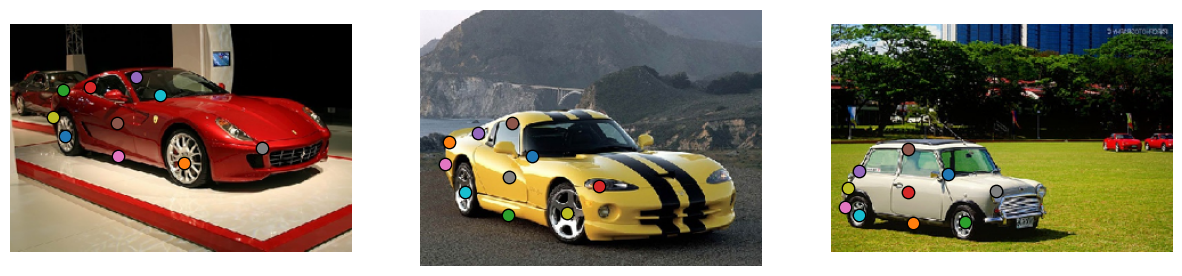

In [36]:
#visualization
#
data_path1 = r'./PF-dataset/car(G)/Cars_006a.mat'
data_path2 = r'./PF-dataset/car(G)/Cars_007a.mat'
data_path3 = r'./PF-dataset/car(G)/Cars_008b.mat'
img_paths = [data_path1,data_path2,data_path3]
keypoints_all = dp.get_all_keypoints(*img_paths)
dp.save_visualization(
image_paths=img_paths,
keypoints_list=keypoints_all,
permutation_matrices=abs_mats,
X_true=None,  # in case of synthetic data where the ground truth is known
energy=best_energy,
rel_perms=P,
result_obj=sim_res
)

# testing with other data and images as well

["d:\\University\\Master'sDegree\\Quantum\\10.Quantum Hardware Design and Optimization and Quantum Computing\\Quantum Computing\\project\\QPermutationSynch\\PF-dataset\\car(G)\\Cars_009b.mat", "d:\\University\\Master'sDegree\\Quantum\\10.Quantum Hardware Design and Optimization and Quantum Computing\\Quantum Computing\\project\\QPermutationSynch\\PF-dataset\\car(G)\\Cars_013b.mat", "d:\\University\\Master'sDegree\\Quantum\\10.Quantum Hardware Design and Optimization and Quantum Computing\\Quantum Computing\\project\\QPermutationSynch\\PF-dataset\\car(G)\\Cars_017a.mat"]
This is the keypoints list [array([[ 86.01382619, 184.56687359,  78.63910835,  92.04768623,
        136.96642212, 128.9212754 , 130.26213318, 206.69102709,
         68.58267494, 162.44272009],
       [160.2722912 , 183.73730248, 134.79599323, 124.06913093,
        115.3535553 , 150.21585779, 168.98786682, 168.31743792,
        148.20457111, 138.81856659]]), array([[ 60.57797165, 179.33478735,  55.67066521,  81.18865867,

c:\Users\sasan\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\sasan\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


{'Cars_009b': array([[0.2805549 , 0.38245696, 0.32913148, ..., 0.23299187, 0.4827137 ,
        0.27525717],
       [0.5110591 , 0.40476662, 0.43136543, ..., 0.16924395, 0.6240198 ,
        0.27621397],
       [0.27171975, 0.40416393, 0.12053382, ..., 0.57509375, 0.32009965,
        0.09384831],
       ...,
       [0.19794564, 0.21664958, 0.3449677 , ..., 0.05677889, 0.69852966,
        0.22613399],
       [0.29520756, 0.4431332 , 0.09600499, ..., 0.60215425, 0.3735537 ,
        0.16230409],
       [0.46446753, 0.6732313 , 0.58594644, ..., 0.04945093, 1.2510496 ,
        0.07019339]], dtype=float32), 'Cars_013b': array([[0.34893787, 0.80953366, 0.44084543, ..., 0.11372468, 0.53622377,
        0.34169134],
       [0.23389694, 1.2627603 , 0.17493977, ..., 0.12937154, 0.6140737 ,
        0.3102886 ],
       [0.34498528, 0.60070974, 0.25404605, ..., 0.        , 0.4337342 ,
        0.09685422],
       ...,
       [0.13885178, 0.20711748, 0.21070902, ..., 0.13484024, 0.47781575,
        0.178

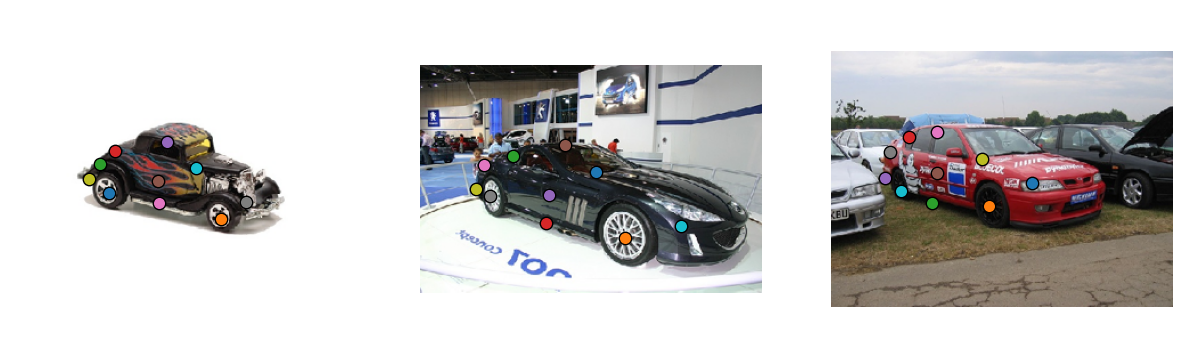

In [47]:
#usage
mat_files = ['Cars_009b.mat','Cars_013b.mat','Cars_017a.mat']
paths = []
for fi in mat_files:
    paths.append(path_joiner(fi))
print(paths)
#
points_list = keypoints_list(paths)
print(f'This is the keypoints list {points_list}')
points_dic = keypoints_dict(mat_files)
print(f'This is the keypoints dict {points_dic}')
#
features = extract_features(points_dic)
print(features)
visualize_similarity(features, list(features.keys()))
#
print("This is the similarity matrix:")
print_similarity_matrix(features)
print("This is the cost matrix:")
print_cost_matrix(features)
#
P = pairwise_permutations(features)
print("these are the pairwise permutations")
print(P)
#
mod = qubo_formulation(P,3)
print(mod)
#
sim_res, best_sample, best_energy = run_dwave_simulated_annealing(mod,10)

print(best_sample)
print(best_energy)
#
abs_mats = extract_absolute_permutation_matrices(best_sample, 3, 1)
print(abs_mats)

#
for k, v in abs_mats.items():
    print(f'matrix {k} is valid : {is_valid_perm_matrix(v)}')

#

cyc_err = cycle_consistency_error(P,abs_mats)
print(f"Cycle consistency error: {cyc_err}")
#visualization
#
data_path1 = r'./PF-dataset/car(G)/Cars_009b.mat'
data_path2 = r'./PF-dataset/car(G)/Cars_013b.mat'
data_path3 = r'./PF-dataset/car(G)/Cars_017a.mat'
data_path4 = r'./PF-dataset/car(G)/Cars_008b.mat'
data_path5 = r'./PF-dataset/car(G)/Cars_008b.mat'
data_path6 = r'./PF-dataset/car(G)/Cars_008b.mat'
img_paths = [data_path1,data_path2,data_path3]
print(img_paths)
keypoints_all = dp.get_all_keypoints(*img_paths)
dp.save_visualization(
image_paths=img_paths,
keypoints_list=keypoints_all,
permutation_matrices=abs_mats,
X_true=None,  # in case of synthetic data where the ground truth is known
energy=best_energy,
rel_perms=P,
result_obj=sim_res
)